In [1]:
import pandas as pd
import numpy as np
from load_rivers import *  # This provides raw_chem_dfs

# ===== USER-SET PARAMETERS =====
# Toggle for the sampled timeframe:
# "water_year"  => use April 1, 2022 through April 1, 2023,
# "full"        => use the full range of sampling dates for that river.
sampled_range_option = "water_year"  # Options: "water_year", "full"

# Window size: number of days before and after the minimum.
window_size = 7  # This yields 15 rows total (from -7 to +7)

# ===== LOAD STREAMFLOW DATA =====
# Load the same CSV file as used in the plotting script.
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Build a list of results.
results = []
for name in river_names:
    # Determine full sampling period.
    full_sample_start = raw_chem_dfs[name].index.min()
    full_sample_end = raw_chem_dfs[name].index.max()
    if sampled_range_option == "full":
        sample_start = full_sample_start
        sample_end = full_sample_end
    else:  # water_year
        sample_start = pd.Timestamp("2022-04-01")
        sample_end = pd.Timestamp("2023-04-01")
    
    # Extract contemporary and historical series (clip to non-negative values).
    cont_series = all_flow[name].loc[sample_start:sample_end].dropna().clip(lower=0)
    hist_series = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))].dropna().clip(lower=0)
    
    results.append({
        "River": name,
        "Period": "Contemporary",
        "Min": cont_series.min(),
        "Max": cont_series.max()
    })
    results.append({
        "River": name,
        "Period": "Historical",
        "Min": hist_series.min(),
        "Max": hist_series.max()
    })

results_df = pd.DataFrame(results)
print(results_df)

NameError: name 'all_flow' is not defined

In [12]:
import pandas as pd
import numpy as np
from load_rivers import *  # This provides raw_chem_dfs

# ===== USER-SET PARAMETERS =====
# Toggle for the sampled timeframe:
# "water_year"  => use April 1, 2022 through April 1, 2023,
# "full"        => use the full range of sampling dates for that river.
sampled_range_option = "water_year"  # Options: "water_year", "full"

# Window size: number of days before and after the minimum.
window_size = 7  # This yields 15 rows total (from -7 to +7)

# ===== LOAD STREAMFLOW DATA =====
# Load the same CSV file as used in the plotting script.
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary mapping each river name to its streamflow Series.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== DETERMINE SAMPLING TIMEFRAMES =====
# For each river, use the chemistry sampling data from load_rivers.py (provided by raw_chem_dfs)
# to get the full sampling period. Then choose the contemporary period based on the toggle.
contemporary_flow = {}
historical_flow = {}

for name in river_names:
    full_sample_start = raw_chem_dfs[name].index.min()
    full_sample_end = raw_chem_dfs[name].index.max()
    if sampled_range_option == "full":
        sample_start = full_sample_start
        sample_end = full_sample_end
    else:  # water_year
        sample_start = pd.Timestamp("2022-04-01")
        sample_end = pd.Timestamp("2023-04-01")
    # Contemporary: data in the sampled period.
    contemporary_flow[name] = all_flow[name].loc[sample_start:sample_end].dropna()
    # Historical: data strictly before the contemporary period.
    historical_flow[name] = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))].dropna()

# ===== FUNCTION TO EXTRACT WINDOW AROUND MINIMUM =====
def window_around_min(series, window):
    """
    Given a pandas Series (with a DatetimeIndex) and a window size (in days),
    return a DataFrame with a 'Date' column and a 'Flow' column covering the period
    from (min_date - window) to (min_date + window), with an additional column 'Offset'
    showing the day offset from the minimum date.
    """
    if series.empty:
        return pd.DataFrame()
    # Find the date where the minimum occurs.
    min_date = series.idxmin()
    # Define the window boundaries.
    start_date = min_date - pd.Timedelta(days=window)
    end_date = min_date + pd.Timedelta(days=window)
    # Extract the data within the window.
    window_series = series.loc[start_date:end_date]
    # Create a DataFrame.
    df_window = window_series.reset_index()
    df_window.columns = ["Date", "Flow"]
    # Compute the day offset (in days) from the min_date.
    df_window["Offset"] = (df_window["Date"] - min_date).dt.days
    return df_window

# ===== BUILD TABLES FOR EACH RIVER & PERIOD =====
results = {}
for name in river_names:
    # For historical period:
    hist_series = historical_flow[name]
    # Ensure no NaNs.
    hist_series = hist_series.dropna()
    hist_window = window_around_min(hist_series, window_size)
    
    # For contemporary period:
    cont_series = contemporary_flow[name]
    cont_series = cont_series.dropna()
    cont_window = window_around_min(cont_series, window_size)
    
    # Merge the two DataFrames on the Offset column.
    merged = pd.merge(hist_window, cont_window, on="Offset", how="outer", suffixes=("_Historical", "_Contemporary"))
    merged.sort_values("Offset", inplace=True)
    results[name] = merged

# ===== PRINT THE TABLES =====
for name, df_table in results.items():
    print(f"\nRiver: {name}")
    print(df_table)



River: Puelo
   Date_Historical  Flow_Historical  Offset Date_Contemporary  \
0       1999-04-03       142.355673      -7        2023-03-17   
1       1999-04-04       126.205955      -6        2023-03-18   
2       1999-04-05       127.219644      -5        2023-03-19   
3       1999-04-06       123.183289      -4        2023-03-20   
4       1999-04-07       115.108393      -3        2023-03-21   
5       1999-04-08       114.100548      -2        2023-03-22   
6       1999-04-09       110.063987      -1        2023-03-23   
7       1999-04-10       102.998579       0        2023-03-24   
8       1999-04-11       102.999750       1        2023-03-25   
9       1999-04-12       104.011969       2        2023-03-26   
10      1999-04-13       142.387061       3        2023-03-27   
11      1999-04-14       353.448163       4        2023-03-28   
12      1999-04-15       306.999733       5        2023-03-29   
13      1999-04-16       233.282376       6        2023-03-30   
14      199

Mann–Whitney U Test Results:
    River  U_statistic       p_value
0   Puelo    2878032.0  5.144723e-01
1  Yelcho    1354895.0  6.169372e-01
2  Palena    1684484.5  5.813508e-04
3  Cisnes    1342892.0  1.967790e-01
4   Aysen    2146500.0  3.142264e-13


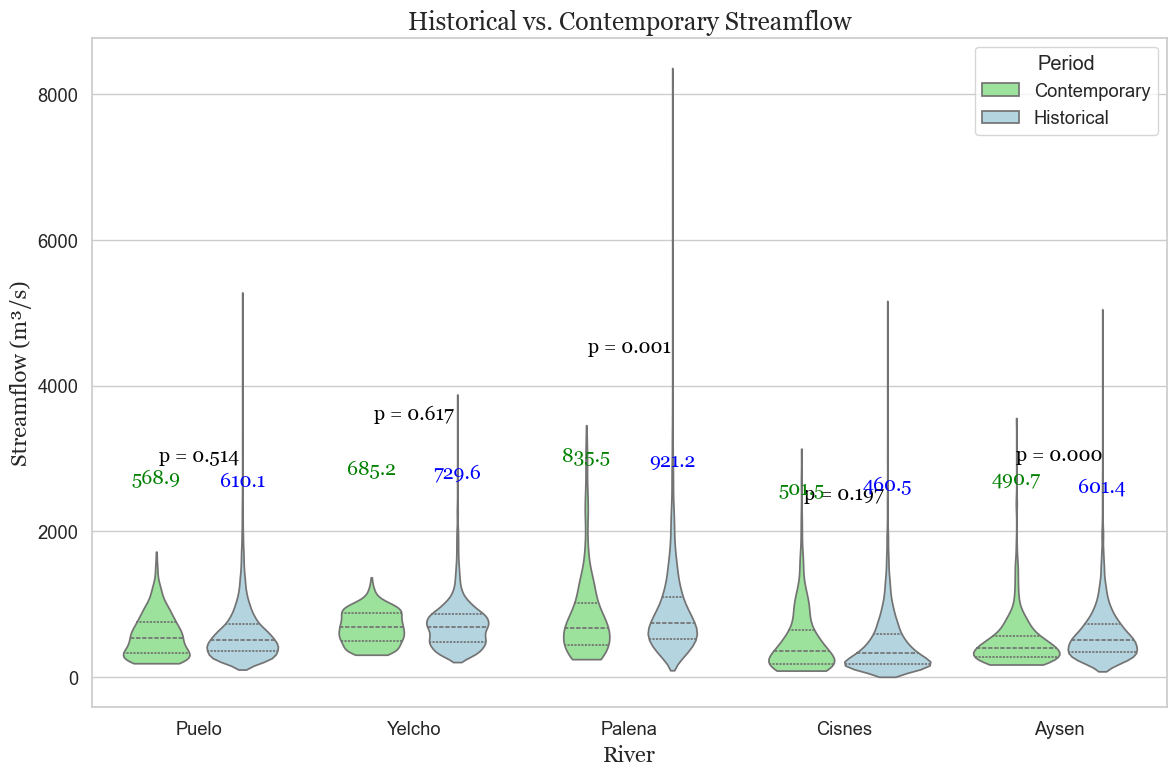

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from load_rivers import *  # This brings in raw_chem_dfs
from scipy.stats import mannwhitneyu

# ===== USER-SET PARAMETERS =====
savefig = True

# Toggle for the sampled timeframe:
# "water_year"  => use April 1, 2022 through April 1, 2023,
# "full"        => use the full range of sampling dates for that river.
sampled_range_option = "water_year"  # Options: "water_year", "full"

# Toggle for which statistic to overlay: "mean" or "median"
overlay_stat = "mean"  # Change to "median" to overlay the median

# Toggle for adjusting the vertical offset of the mean/median labels (in the same units as flow)
stat_y_offset = 2000  # Set to a positive value to move the labels upward; negative to move them downward.

# Offset to shift the p-value annotation upward (as a fraction of the maximum flow)
pval_y_offset_frac = 3  # 5% of the maximum flow


# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary mapping each river name to its streamflow Series.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== DETERMINE SAMPLING TIMEFRAMES =====
contemporary_data = []  # List for contemporary data pieces.
historical_data = []    # List for historical data pieces.

for name in river_names:
    full_sample_start = raw_chem_dfs[name].index.min()
    full_sample_end = raw_chem_dfs[name].index.max()
    
    if sampled_range_option == "full":
        sample_start = full_sample_start
        sample_end = full_sample_end
    else:  # water_year
        sample_start = pd.Timestamp("2022-04-01")
        sample_end = pd.Timestamp("2023-04-01")
    
    # Extract contemporary streamflow (drop NaNs and clip to ≥0).
    cont_series = all_flow[name].loc[sample_start:sample_end].dropna().clip(lower=0)
    cont_df = pd.DataFrame({
        "River": name,
        "Period": "Contemporary",
        "Flow": cont_series.values
    })
    contemporary_data.append(cont_df)
    
    # Extract historical streamflow: all values strictly before sample_start.
    hist_series = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))].dropna().clip(lower=0)
    hist_df = pd.DataFrame({
        "River": name,
        "Period": "Historical",
        "Flow": hist_series.values
    })
    historical_data.append(hist_df)

# Combine data into one DataFrame.
df = pd.concat(contemporary_data + historical_data, ignore_index=True)

# ===== PLOTTING VIOLIN PLOTS =====
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", font_scale=1.2)
ax = sns.violinplot(x="River", y="Flow", hue="Period", data=df, split=False, inner="quartile",
                    palette={"Historical": "lightblue", "Contemporary": "lightgreen"},
                    cut=0)
# Do not remove the legend so that it remains visible.
# (By default, Seaborn adds a legend for the hue.)

plt.title("Historical vs. Contemporary Streamflow", fontsize=18, fontname="Georgia")
plt.xlabel("River", fontsize=16, fontname="Georgia")
plt.ylabel("Streamflow (m³/s)", fontsize=16, fontname="Georgia")

# ===== STATISTICAL TEST & ANNOTATION =====
test_results = []
x_positions = ax.get_xticks()  # positions for each river on the x-axis
for i, river in enumerate(df["River"].unique()):
    hist_vals = df.loc[(df["River"] == river) & (df["Period"] == "Historical"), "Flow"]
    cont_vals = df.loc[(df["River"] == river) & (df["Period"] == "Contemporary"), "Flow"]
    
    # Perform the Mann–Whitney U test.
    stat, p_value = mannwhitneyu(hist_vals, cont_vals, alternative='two-sided')
    test_results.append({"River": river, "U_statistic": stat, "p_value": p_value})
    
    # Compute overlay statistic.
    if overlay_stat == "mean":
        hist_stat = hist_vals.mean()
        cont_stat = cont_vals.mean()
    else:
        hist_stat = hist_vals.median()
        cont_stat = cont_vals.median()
    
    # Compute the 75th percentile for annotation positioning.
    combined = pd.concat([hist_vals, cont_vals])
    percentile_75 = np.percentile(combined, 75)
    # Define a vertical offset.
    pval_offset = percentile_75 * pval_y_offset_frac
    # Annotate p-value at the center of the category.
    ax.text(x_positions[i], percentile_75 + pval_offset, f"p = {p_value:.3f}", 
            ha="center", va="bottom", fontsize=14, fontname="Georgia", color="black")
    # Annotate the overlay statistic values near each violin.
    offset = 0.2
    ax.text(x_positions[i] - offset, hist_stat + stat_y_offset, f"{cont_stat:.1f}", 
            ha="center", va="bottom", fontsize=14, fontname="Georgia", color="green")
    ax.text(x_positions[i] + offset, cont_stat  + stat_y_offset, f"{hist_stat:.1f}", 
            ha="center", va="bottom", fontsize=14, fontname="Georgia", color="blue")

# Print test results table.
results_df = pd.DataFrame(test_results)
print("Mann–Whitney U Test Results:")
print(results_df)

plt.tight_layout()
if savefig:
    plt.savefig("../../../figures/hydrological/water_year_stats/annual_streamflow.jpeg", bbox_inches='tight')
plt.show()


Mann–Whitney U Test Results:
    River  U_statistic       p_value
0   Puelo    2878032.0  5.144723e-01
1  Yelcho    1354895.0  6.169372e-01
2  Palena    1684484.5  5.813508e-04
3  Cisnes    1342892.0  1.967790e-01
4   Aysen    2146500.0  3.142264e-13


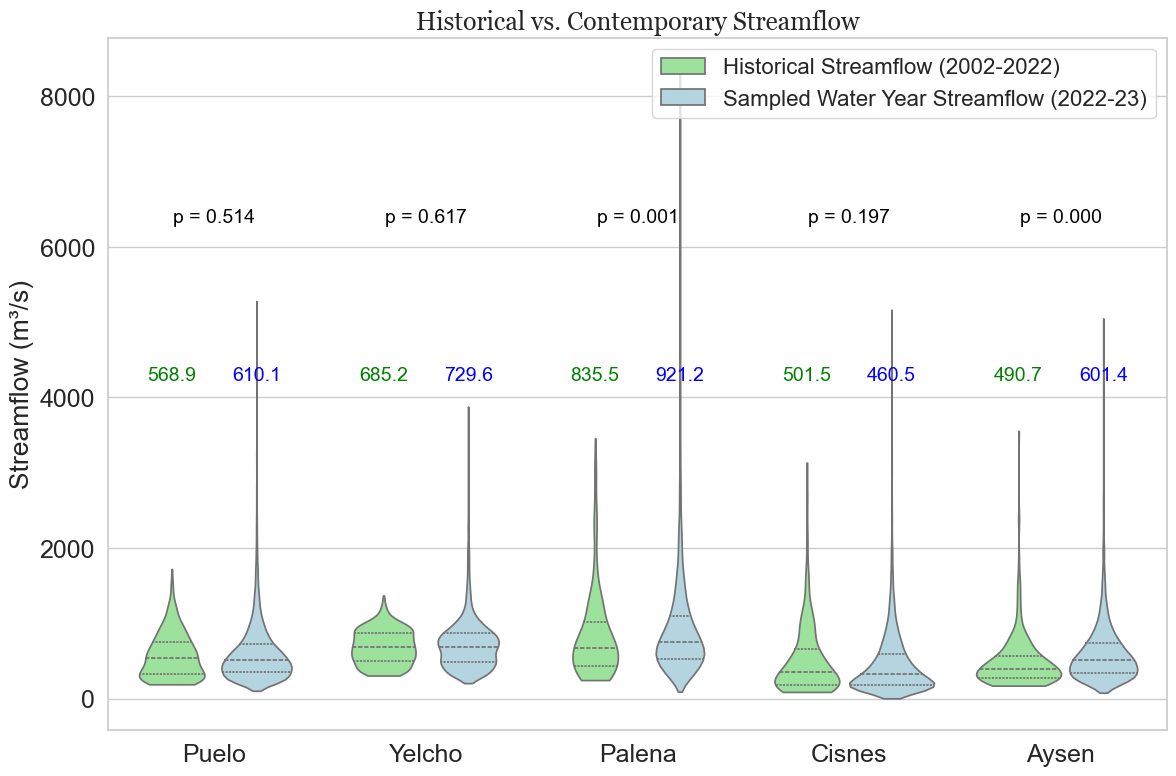

In [14]:
####### TEMP PLOTTING SCRIPT FOR PRESENTATION DEFENSE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator, FuncFormatter
from load_rivers import *  # This brings in raw_chem_dfs
from scipy.stats import mannwhitneyu

# ===== USER-SET PARAMETERS =====
savefig = True

# Toggle for the sampled timeframe:
sampled_range_option = "water_year"  # Options: "water_year", "full"

# Toggle for which statistic to overlay: "mean" or "median"
overlay_stat = "mean"

# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary mapping each river name to its streamflow Series.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== DETERMINE SAMPLING TIMEFRAMES =====
contemporary_data = []
historical_data = []

for name in river_names:
    full_sample_start = raw_chem_dfs[name].index.min()
    full_sample_end = raw_chem_dfs[name].index.max()
    
    if sampled_range_option == "full":
        sample_start = full_sample_start
        sample_end = full_sample_end
    else:
        sample_start = pd.Timestamp("2022-04-01")
        sample_end = pd.Timestamp("2023-04-01")
    
    cont_series = all_flow[name].loc[sample_start:sample_end].dropna().clip(lower=0)
    cont_df = pd.DataFrame({
        "River": name,
        "Period": "Contemporary",
        "Flow": cont_series.values
    })
    contemporary_data.append(cont_df)
    
    hist_series = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))].dropna().clip(lower=0)
    hist_df = pd.DataFrame({
        "River": name,
        "Period": "Historical",
        "Flow": hist_series.values
    })
    historical_data.append(hist_df)

# Combine data into one DataFrame.
df = pd.concat(contemporary_data + historical_data, ignore_index=True)

# ===== PLOTTING VIOLIN PLOTS =====
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", font_scale=1.2)
ax = sns.violinplot(x="River", y="Flow", hue="Period", data=df, split=False, inner="quartile",
                    palette={"Historical": "lightblue", "Contemporary": "lightgreen"},
                    cut=0)

#  Now grab the existing legend handles & labels
handles, labels = ax.get_legend_handles_labels()

#  Define your new label names
new_labels = ["Historical Streamflow (2002-2022)", "Sampled Water Year Streamflow (2022-23)"]   # in the same order as `labels`

#  Replace the legend
ax.legend(handles, new_labels, title="", fontsize=16, title_fontsize=0)

plt.title("Historical vs. Contemporary Streamflow", fontsize=18, fontname="Georgia")
plt.xlabel("", fontsize=18, fontname="Arial")
plt.ylabel("Streamflow (m³/s)", fontsize=19, fontname="Arial")

ax.tick_params(axis='both', which='major', labelsize=18)

# ===== STATISTICAL TEST & ANNOTATION =====
# Compute overall maximum flow for setting label heights
overall_max = df["Flow"].max()
pval_height = 0.75 * overall_max
stat_label_height = 0.5 * overall_max

test_results = []
x_positions = ax.get_xticks()

for i, river in enumerate(df["River"].unique()):
    hist_vals = df.loc[(df["River"] == river) & (df["Period"] == "Historical"), "Flow"]
    cont_vals = df.loc[(df["River"] == river) & (df["Period"] == "Contemporary"), "Flow"]
    
    # Perform Mann–Whitney U test
    stat, p_value = mannwhitneyu(hist_vals, cont_vals, alternative='two-sided')
    test_results.append({"River": river, "U_statistic": stat, "p_value": p_value})
    
    # Compute overlay statistic
    if overlay_stat == "mean":
        hist_stat = hist_vals.mean()
        cont_stat = cont_vals.mean()
    else:
        hist_stat = hist_vals.median()
        cont_stat = cont_vals.median()
    
    # Annotate p-value at fixed height
    ax.text(x_positions[i], pval_height, f"p = {p_value:.3f}",
            ha="center", va="bottom", fontsize=14, fontname="Arial", color="black")
    
    # Annotate means/medians at fixed height (corrected)
    offset = 0.2
    ax.text(x_positions[i] - offset, stat_label_height, f"{cont_stat:.1f}",
            ha="center", va="bottom", fontsize=14, fontname="Arial", color="green")
    ax.text(x_positions[i] + offset, stat_label_height, f"{hist_stat:.1f}",
            ha="center", va="bottom", fontsize=14, fontname="Arial", color="blue")

# Print test results table
results_df = pd.DataFrame(test_results)
print("Mann–Whitney U Test Results:")
print(results_df)

plt.tight_layout()
if savefig:
    plt.savefig("../../../figures/hydrological/water_year_stats/annual_streamflow.jpeg", bbox_inches='tight')
plt.show()


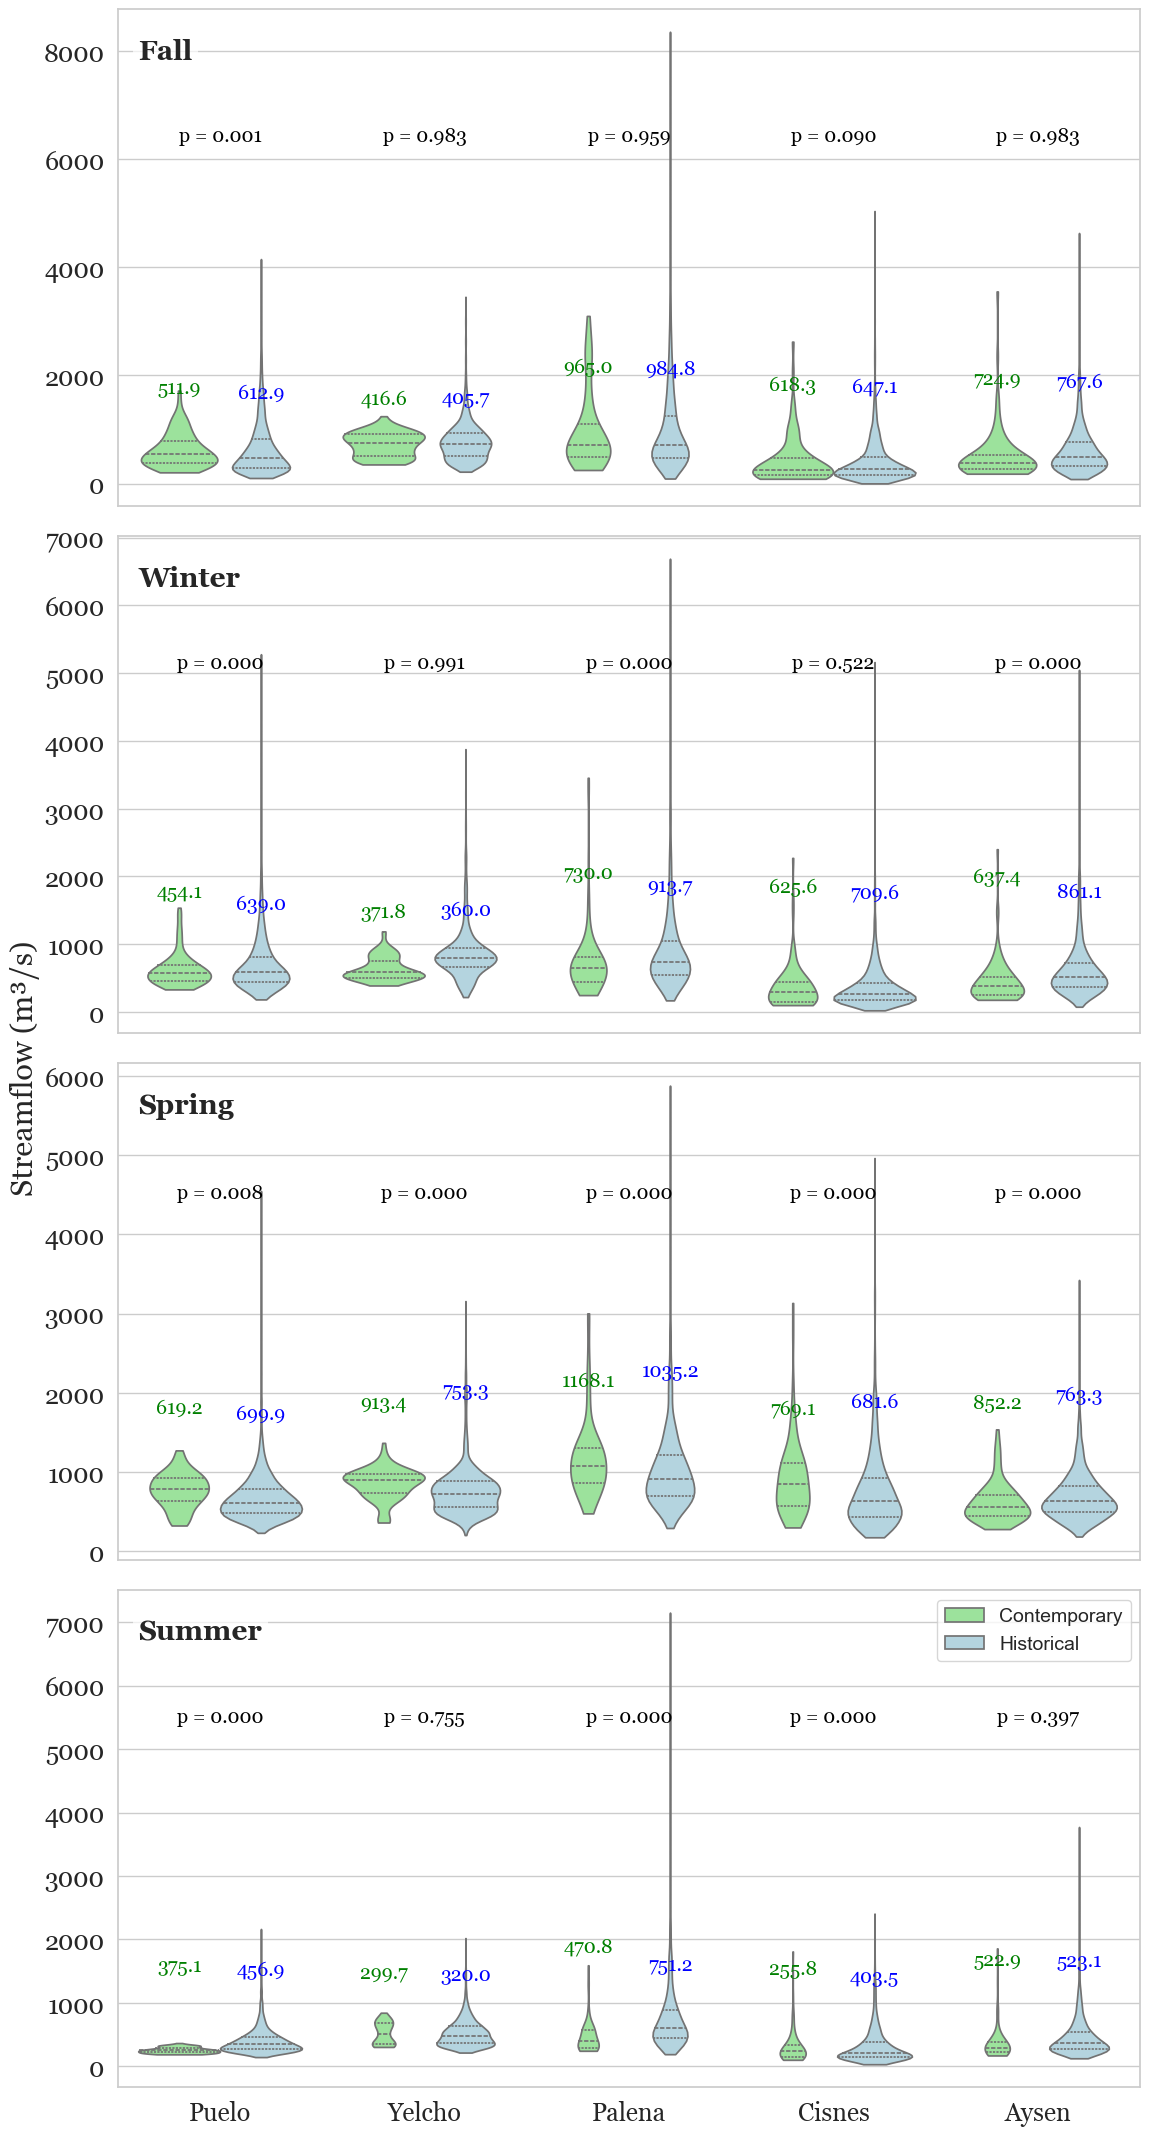

Combined Statistical Test Results:
     River  Season  U_statistic       p_value
0    Aysen    Fall     131693.0  6.209065e-04
1   Cisnes    Fall      87010.0  9.828004e-01
2   Palena    Fall      92627.0  9.592199e-01
3    Puelo    Fall     157648.0  8.991607e-02
4   Yelcho    Fall      83417.0  9.828536e-01
5    Aysen  Winter     148137.0  1.656155e-08
6   Cisnes  Winter      88932.0  9.913318e-01
7   Palena  Winter     118347.0  4.485115e-04
8    Puelo  Winter     184681.0  5.217360e-01
9   Yelcho  Winter     121516.0  1.644676e-12
10   Aysen  Spring     127744.0  7.740192e-03
11  Cisnes  Spring      65166.0  1.728962e-05
12  Palena  Spring      74738.0  1.846516e-04
13   Puelo  Spring     123362.0  6.034542e-07
14  Yelcho  Spring      56175.0  5.915963e-08
15   Aysen  Summer     137321.0  4.731626e-05
16  Cisnes  Summer      83619.0  7.553408e-01
17  Palena  Summer     135762.5  3.111126e-13
18   Puelo  Summer     276814.0  2.061171e-21
19  Yelcho  Summer      76934.0  3.970646e-01

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from load_rivers import *  # This brings in raw_chem_dfs

# ===== USER-SET PARAMETERS =====
savefig = True

# Toggle for the sampled timeframe:
# "water_year"  => use April 1, 2022 through April 1, 2023,
# "full"        => use the full range of sampling dates for that river.
sampled_range_option = "water_year"  # Options: "water_year", "full"

# Toggle for which statistic to overlay: "mean" or "median"
overlay_stat = "mean"  # Change to "mean" to overlay the mean

# Vertical offset (in flow units) to shift the overlay statistic labels upward.
stat_y_offset = 1000

# Vertical offset for p-value annotation: it will be placed at 75% of the overall seasonal maximum.
# (No additional offset factor is applied here since we want it exactly at 75% of the max.)
pval_y_position_frac = 0.75

# ===== DEFINE SEASON FUNCTION =====
def get_season(date):
    """
    Given a pd.Timestamp, returns the season based on a water year starting on April 1.
    - Fall:    April 1 – June 30
    - Winter:  July 1 – September 30
    - Spring:  October 1 – December 31
    - Summer:  January 1 – March 31
    """
    month = date.month
    if 4 <= month <= 6:
        return "Fall"
    elif 7 <= month <= 9:
        return "Winter"
    elif 10 <= month <= 12:
        return "Spring"
    else:
        return "Summer"

# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary mapping each river name to its streamflow Series.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== DETERMINE SAMPLING TIMEFRAMES & BUILD DATAFRAMES =====
# For each river, historical flow is defined as all data strictly before the contemporary period.
# Contemporary flow is determined by the sampled_range_option.
contemporary_data = []  # To store contemporary DataFrame pieces.
historical_data = []    # To store historical DataFrame pieces.

for name in river_names:
    # Full sampling period from chemistry sampling data (from load_rivers.py)
    full_sample_start = raw_chem_dfs[name].index.min()
    full_sample_end = raw_chem_dfs[name].index.max()
    
    if sampled_range_option == "full":
        sample_start = full_sample_start
        sample_end = full_sample_end
    else:  # water_year
        sample_start = pd.Timestamp("2022-04-01")
        sample_end = pd.Timestamp("2023-04-01")
    
    # Extract contemporary streamflow and assign season.
    cont_series = all_flow[name].loc[sample_start:sample_end].dropna().clip(lower=0)
    cont_df = pd.DataFrame({
        "River": name,
        "Period": "Contemporary",
        "Flow": cont_series.values,
        "Date": cont_series.index
    })
    cont_df["Season"] = cont_df["Date"].apply(get_season)
    contemporary_data.append(cont_df)
    
    # Extract historical streamflow and assign season.
    hist_series = all_flow[name].loc[:(sample_start - pd.Timedelta(days=1))].dropna().clip(lower=0)
    hist_df = pd.DataFrame({
        "River": name,
        "Period": "Historical",
        "Flow": hist_series.values,
        "Date": hist_series.index
    })
    hist_df["Season"] = hist_df["Date"].apply(get_season)
    historical_data.append(hist_df)

# Combine data into one DataFrame.
df_all = pd.concat(contemporary_data + historical_data, ignore_index=True)

# ===== PLOTTING VIOLIN PLOTS BY SEASON (OVERARCHING PANEL) =====
# Create one figure with 4 rows (one per season) in a single column.
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 24), sharex=True)
plt.subplots_adjust(hspace=0.01)  # minimal vertical space between subplots

# We'll store statistical test results in a list.
all_test_results = []

# Loop over the seasons.
season_order = ["Fall", "Winter", "Spring", "Summer"]
for i, season in enumerate(season_order):
    ax = axes[i]
    df_season = df_all[df_all["Season"] == season]
    
    # Create the violin plot.
    sns.violinplot(x="River", y="Flow", hue="Period", data=df_season, split=False, inner="quartile",
                   palette={"Historical": "lightblue", "Contemporary": "lightgreen"},
                   cut=0, ax=ax)
    
    # Overlay the season name on the plot (in the top left corner).
    ax.text(0.02, 0.90, season, transform=ax.transAxes, fontsize=20, fontname="Georgia",
            fontweight="bold", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
    # Hide the legend on all subplots except perhaps the bottom one.
    if i < len(axes)-1:
        ax.get_legend().remove()
    else:
        # Place the legend on the bottom subplot.
        ax.legend(title="", loc="upper right", fontsize=14)
    
    # Get x-axis positions for the river categories.
    x_positions = ax.get_xticks()
    
    # Compute a common maximum value for the season for positioning the p-value annotations.
    seasonal_max = df_season["Flow"].max()
    pval_y = pval_y_position_frac * seasonal_max  # 75% of seasonal max (adjust as desired)
    
    # For each river in this season, perform the statistical test and annotate.
    test_results = []
    for j, river in enumerate(sorted(df_season["River"].unique())):
        hist_vals = df_season.loc[(df_season["River"] == river) & (df_season["Period"] == "Historical"), "Flow"]
        cont_vals = df_season.loc[(df_season["River"] == river) & (df_season["Period"] == "Contemporary"), "Flow"]
        if len(hist_vals)==0 or len(cont_vals)==0:
            continue
        stat, p_value = mannwhitneyu(hist_vals, cont_vals, alternative='two-sided')
        test_results.append({"River": river, "Season": season, "U_statistic": stat, "p_value": p_value})
        
        # Overlay statistic (mean or median).
        if overlay_stat == "mean":
            hist_stat = hist_vals.mean()
            cont_stat = cont_vals.mean()
        else:
            hist_stat = hist_vals.median()
            cont_stat = cont_vals.median()
        
        # Annotate p-value at the fixed vertical position (pval_y) and at the river's x-position.
        ax.text(x_positions[j], pval_y, f"p = {p_value:.3f}",
                ha="center", va="bottom", fontsize=14, fontname="Georgia", color="black")
        # Annotate the overlay statistic values.
        offset = 0.2
        ax.text(x_positions[j] - offset, hist_stat + stat_y_offset, f"{cont_stat:.1f}",
                ha="center", va="bottom", fontsize=14, fontname="Georgia", color="green")
        ax.text(x_positions[j] + offset, cont_stat + stat_y_offset, f"{hist_stat:.1f}",
                ha="center", va="bottom", fontsize=14, fontname="Georgia", color="blue")
    
    season_results_df = pd.DataFrame(test_results)
    all_test_results.append(season_results_df)
    
    # Adjust font sizes for tick labels.
    for label in ax.get_xticklabels():
        label.set_fontsize(18)
        label.set_fontname('Georgia')
    for label in ax.get_yticklabels():
        label.set_fontsize(18)
        label.set_fontname('Georgia')
    
    ax.minorticks_off()
    ax.set_ylabel("")

# Add common x-axis label on the bottom.
axes[-1].set_xlabel("", fontsize=16, fontname="Georgia")
# Optionally, add a common y-axis label.
fig.text(0.04, 0.5, "Streamflow (m³/s)", va="center", rotation="vertical", fontsize=22, fontname="Georgia")

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
if savefig:
    plt.savefig(f"../../../figures/hydrological/water_year_stats/seasonal_streamflow_{overlay_stat}.jpeg", bbox_inches='tight')
plt.show()

# Combine and print all test results.
combined_results = pd.concat(all_test_results, ignore_index=True)
print("Combined Statistical Test Results:")
print(combined_results)


/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_83588/2707860821.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 1, 0.90])


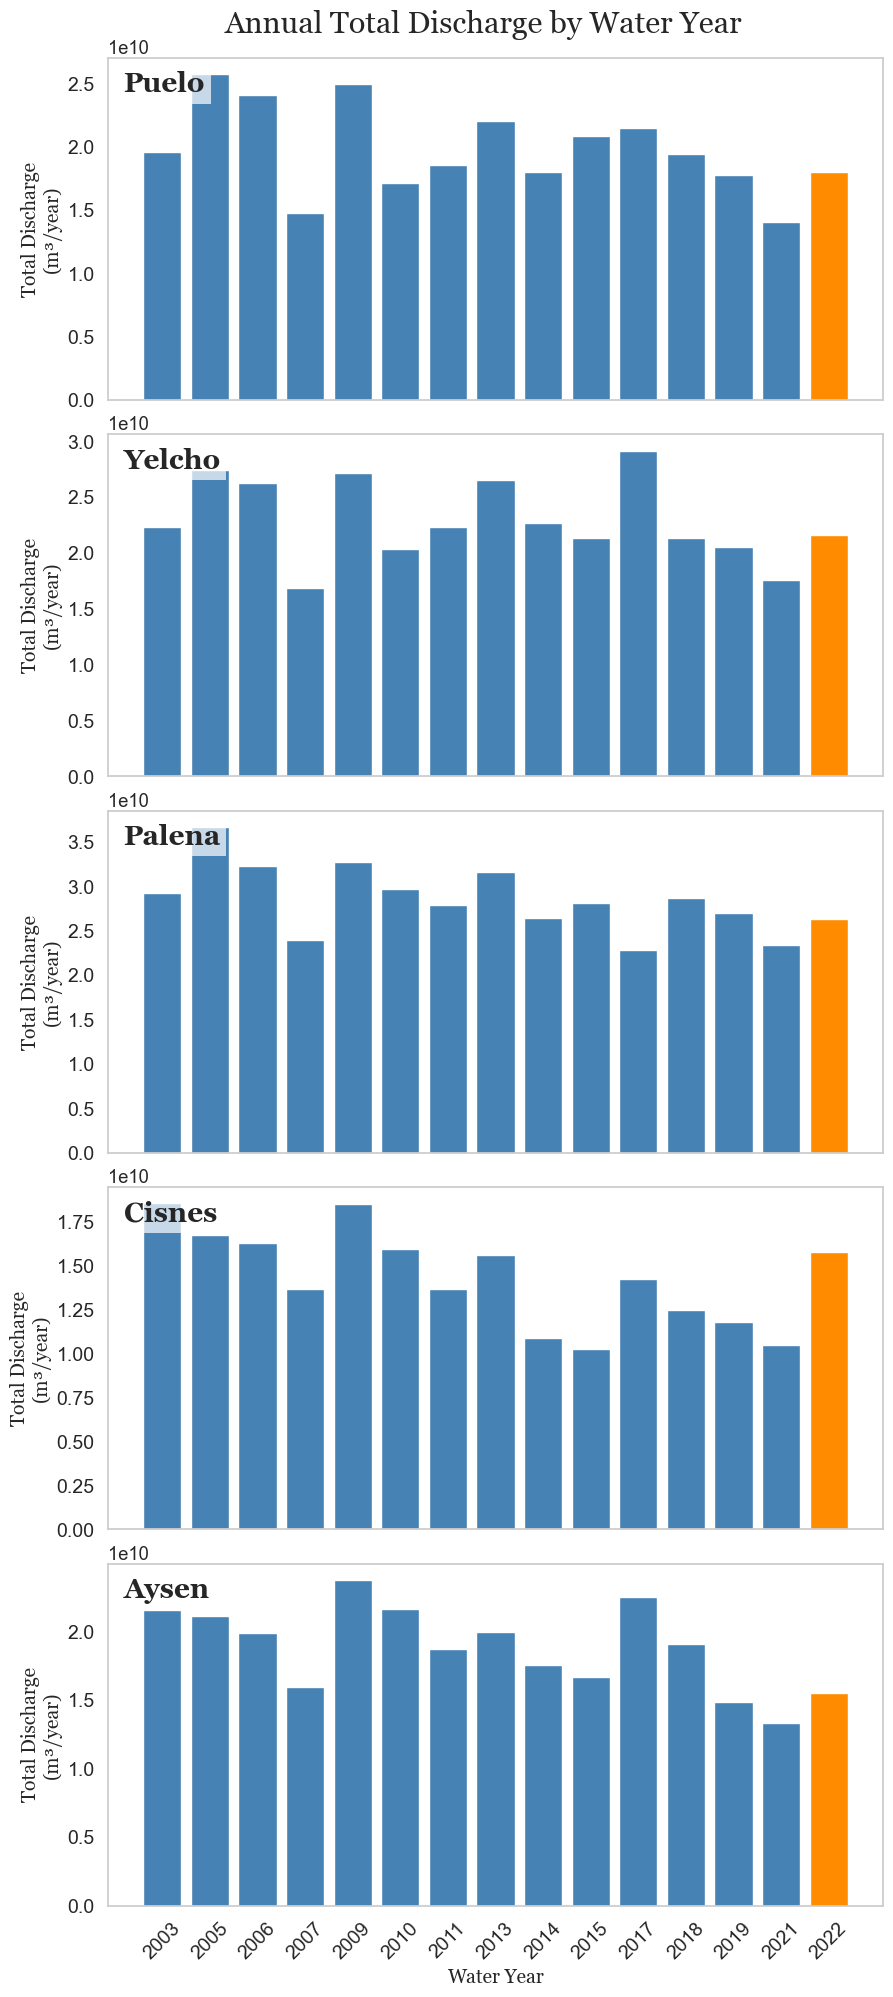

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from load_rivers import *  # This brings in raw_chem_dfs

# ===== USER-SET PARAMETERS =====
savefig = True

# ===== UTILITY FUNCTIONS =====
def water_year(date):
    """
    For a given date (pd.Timestamp), returns the water year.
    Water year runs from April 1 to March 31.
    If the month is January–March, assign the previous year.
    """
    return date.year - 1 if date.month < 4 else date.year

def expected_days_in_water_year(wy):
    """
    Returns the number of days in a water year that starts on April 1 of year wy
    and ends on March 31 of year wy+1.
    """
    start = pd.Timestamp(year=wy, month=4, day=1)
    end = pd.Timestamp(year=wy+1, month=3, day=31)
    return (end - start).days + 1

# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary of the entire daily mean streamflow Series (in m³/s) for each river.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== COMPUTE ANNUAL TOTAL DISCHARGE FOR EACH RIVER =====
# Convert daily mean (m³/s) to daily total (m³/day) by multiplying by 86400.
annual_totals = {}
for name in river_names:
    df = all_flow[name].dropna().to_frame(name="Flow")
    df["DailyTotal"] = df["Flow"] * 86400  # m³/day
    df["WaterYear"] = df.index.map(water_year)
    group = df.groupby("WaterYear")["DailyTotal"].agg(["sum", "count"])
    complete_groups = []
    for wy, row in group.iterrows():
        expected = expected_days_in_water_year(wy)
        if row["count"] == expected:
            complete_groups.append((wy, row["sum"]))
    river_df = pd.DataFrame(complete_groups, columns=["WaterYear", "TotalDischarge"])
    annual_totals[name] = river_df

# ===== FIND COMMON WATER YEARS ACROSS ALL RIVERS =====
common_years = set(annual_totals[river_names[0]]["WaterYear"])
for name in river_names[1:]:
    common_years = common_years.intersection(set(annual_totals[name]["WaterYear"]))
common_years = sorted(common_years)

# Filter each river's DataFrame to only include the common water years.
for name in river_names:
    annual_totals[name] = annual_totals[name][annual_totals[name]["WaterYear"].isin(common_years)]

# ===== PLOTTING PANEL FIGURE =====
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 24), sharex=True, 
                         gridspec_kw={'hspace': 0.1})
# Remove gridlines from each subplot.
for ax in axes:
    ax.grid(False)

# Define bar colors.
default_color = "steelblue"
sampled_year_color = "darkorange"
# The last water year in common_years is the sampled (most recent) year.
sampled_year = common_years[-1]

for i, name in enumerate(river_names):
    ax = axes[i]
    river_df = annual_totals[name]
    # Create a list of colors: if the water year equals sampled_year, use sampled_year_color.
    bar_colors = [sampled_year_color if wy == sampled_year else default_color for wy in river_df["WaterYear"]]
    ax.bar(river_df["WaterYear"].astype(str), river_df["TotalDischarge"], color=bar_colors)
    # Set y-axis label using a professional font.
    ax.set_ylabel("Total Discharge\n(m³/year)", fontsize=14, fontname="Georgia")
    # Remove x-axis label for all but the bottom subplot.
    if i < len(axes)-1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Water Year", fontsize=14, fontname="Georgia")
    # Overlay the river name in bold Georgia on the plot.
    ax.text(0.02, 0.9, name, transform=ax.transAxes, fontsize=20, fontname="Georgia", 
            fontweight="bold", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    # Optionally, adjust tick parameters for professional appearance.
    ax.tick_params(axis='x', labelrotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

# Add a common x-axis label if desired.
#fig.text(0.5, 0.02, "Water Year", ha="center", fontsize=16, fontname="Georgia")
# Add a common title if desired.
fig.suptitle("Annual Total Discharge by Water Year", fontsize=22, fontname="Georgia", y=0.9)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.90])
if savefig:
    plt.savefig("../../../figures/hydrological/water_year_stats/annual_total_discharge.jpeg", bbox_inches='tight')
plt.show()


/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_83588/632481456.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])


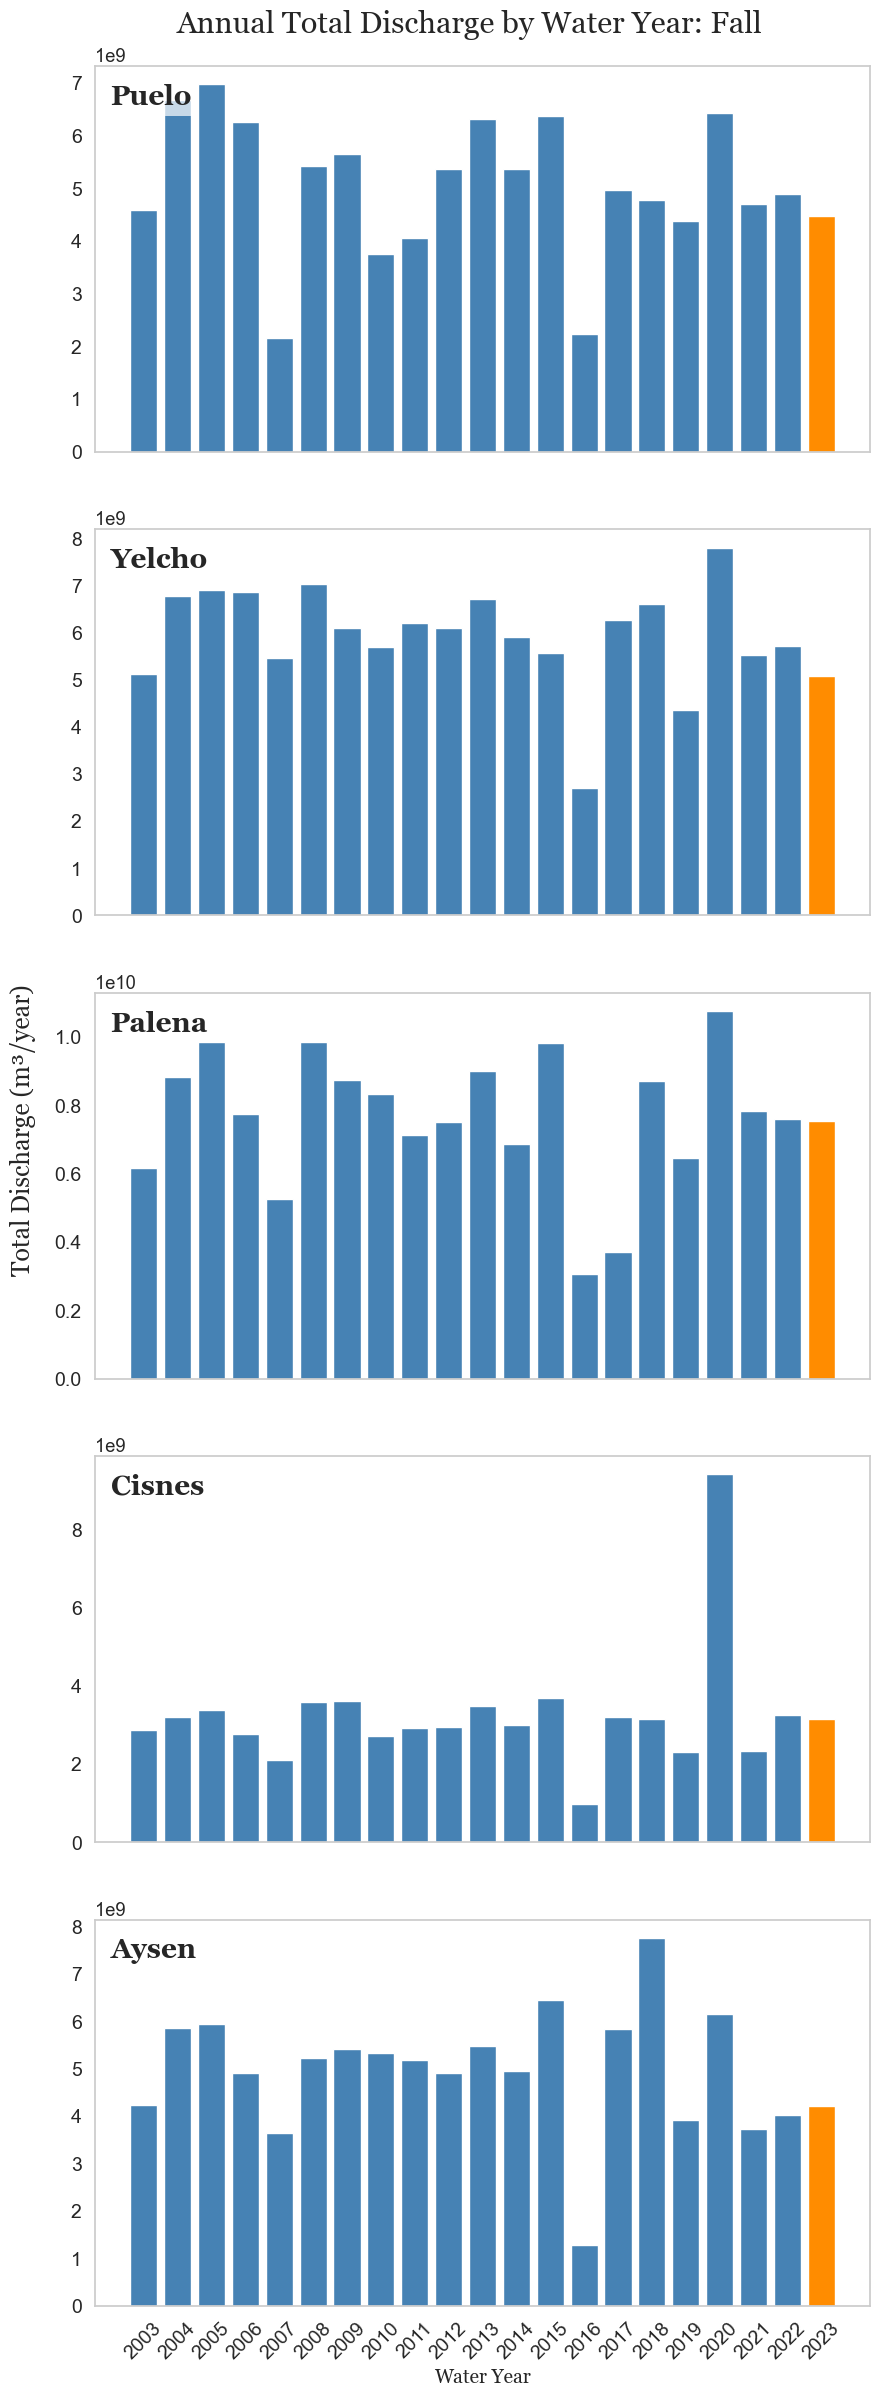

/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_83588/632481456.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])


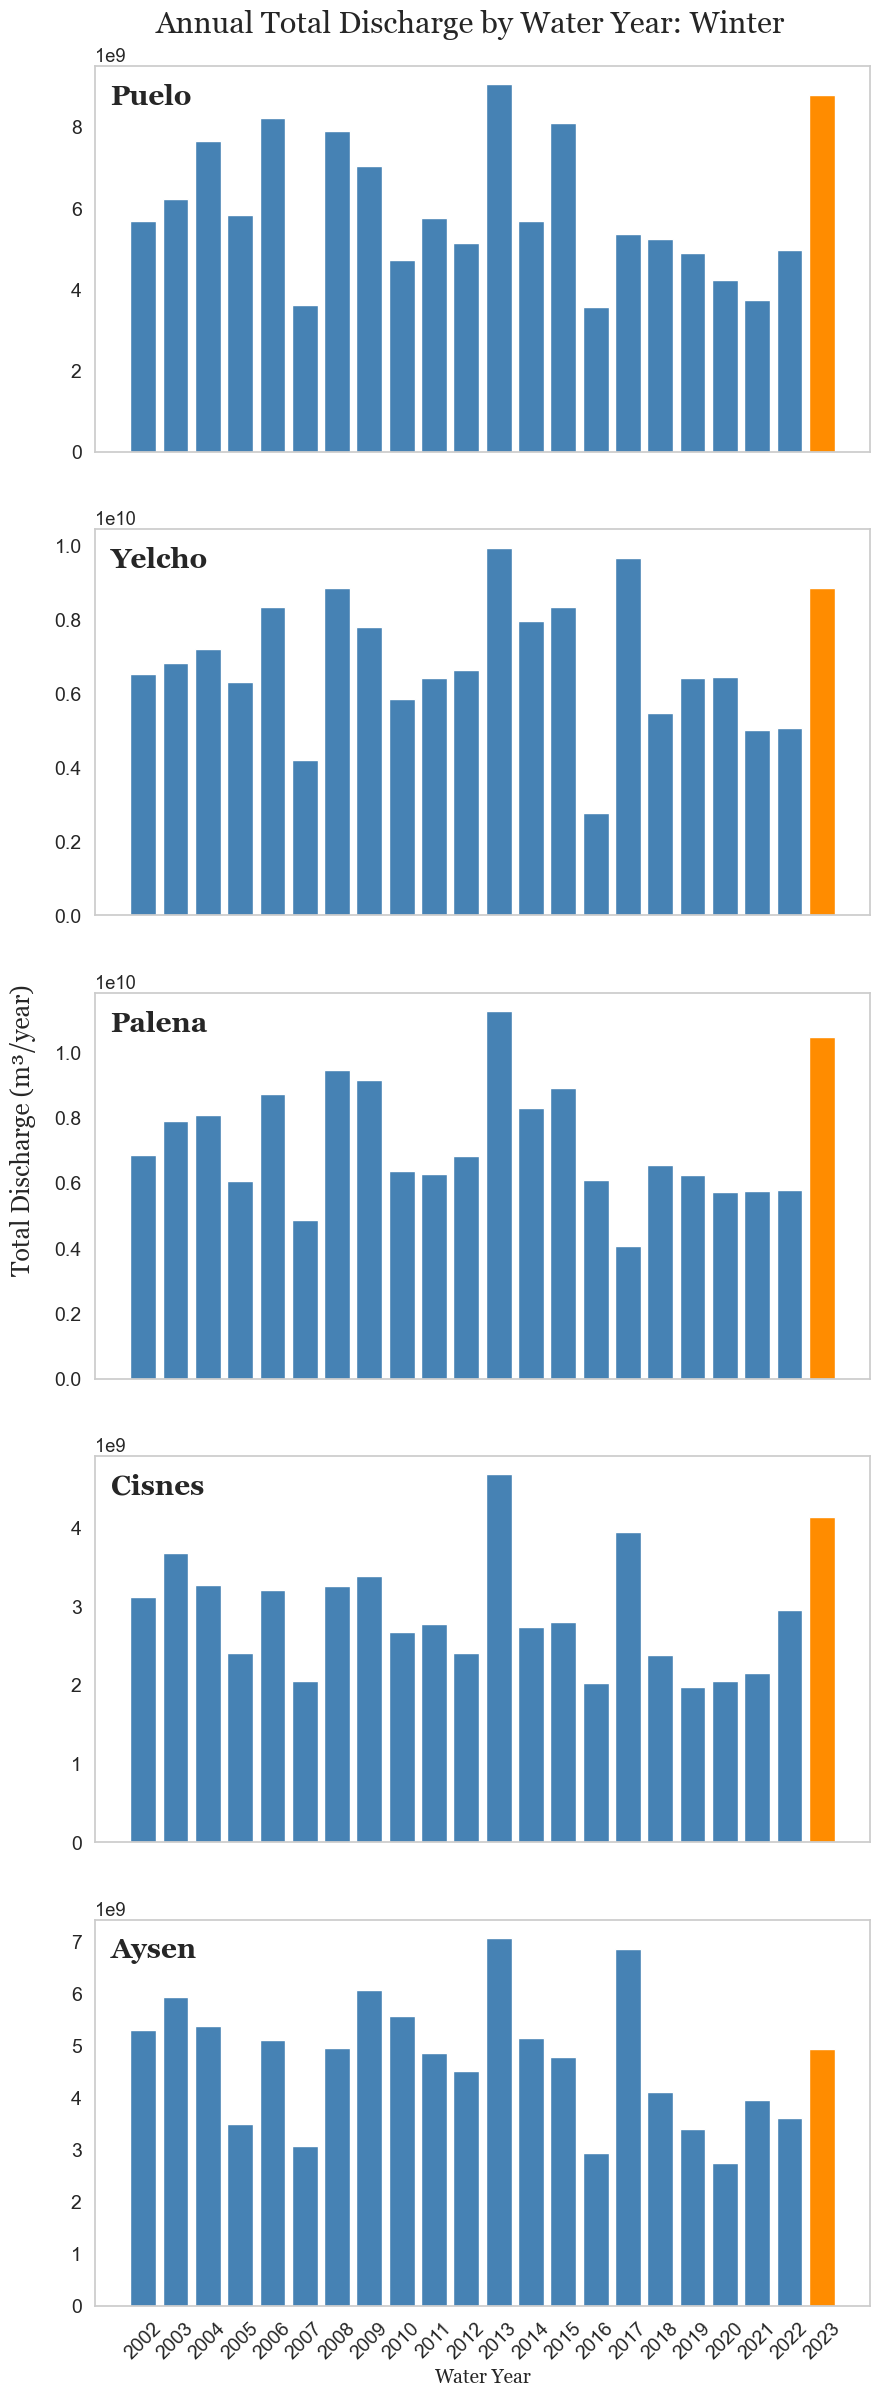

/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_83588/632481456.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])


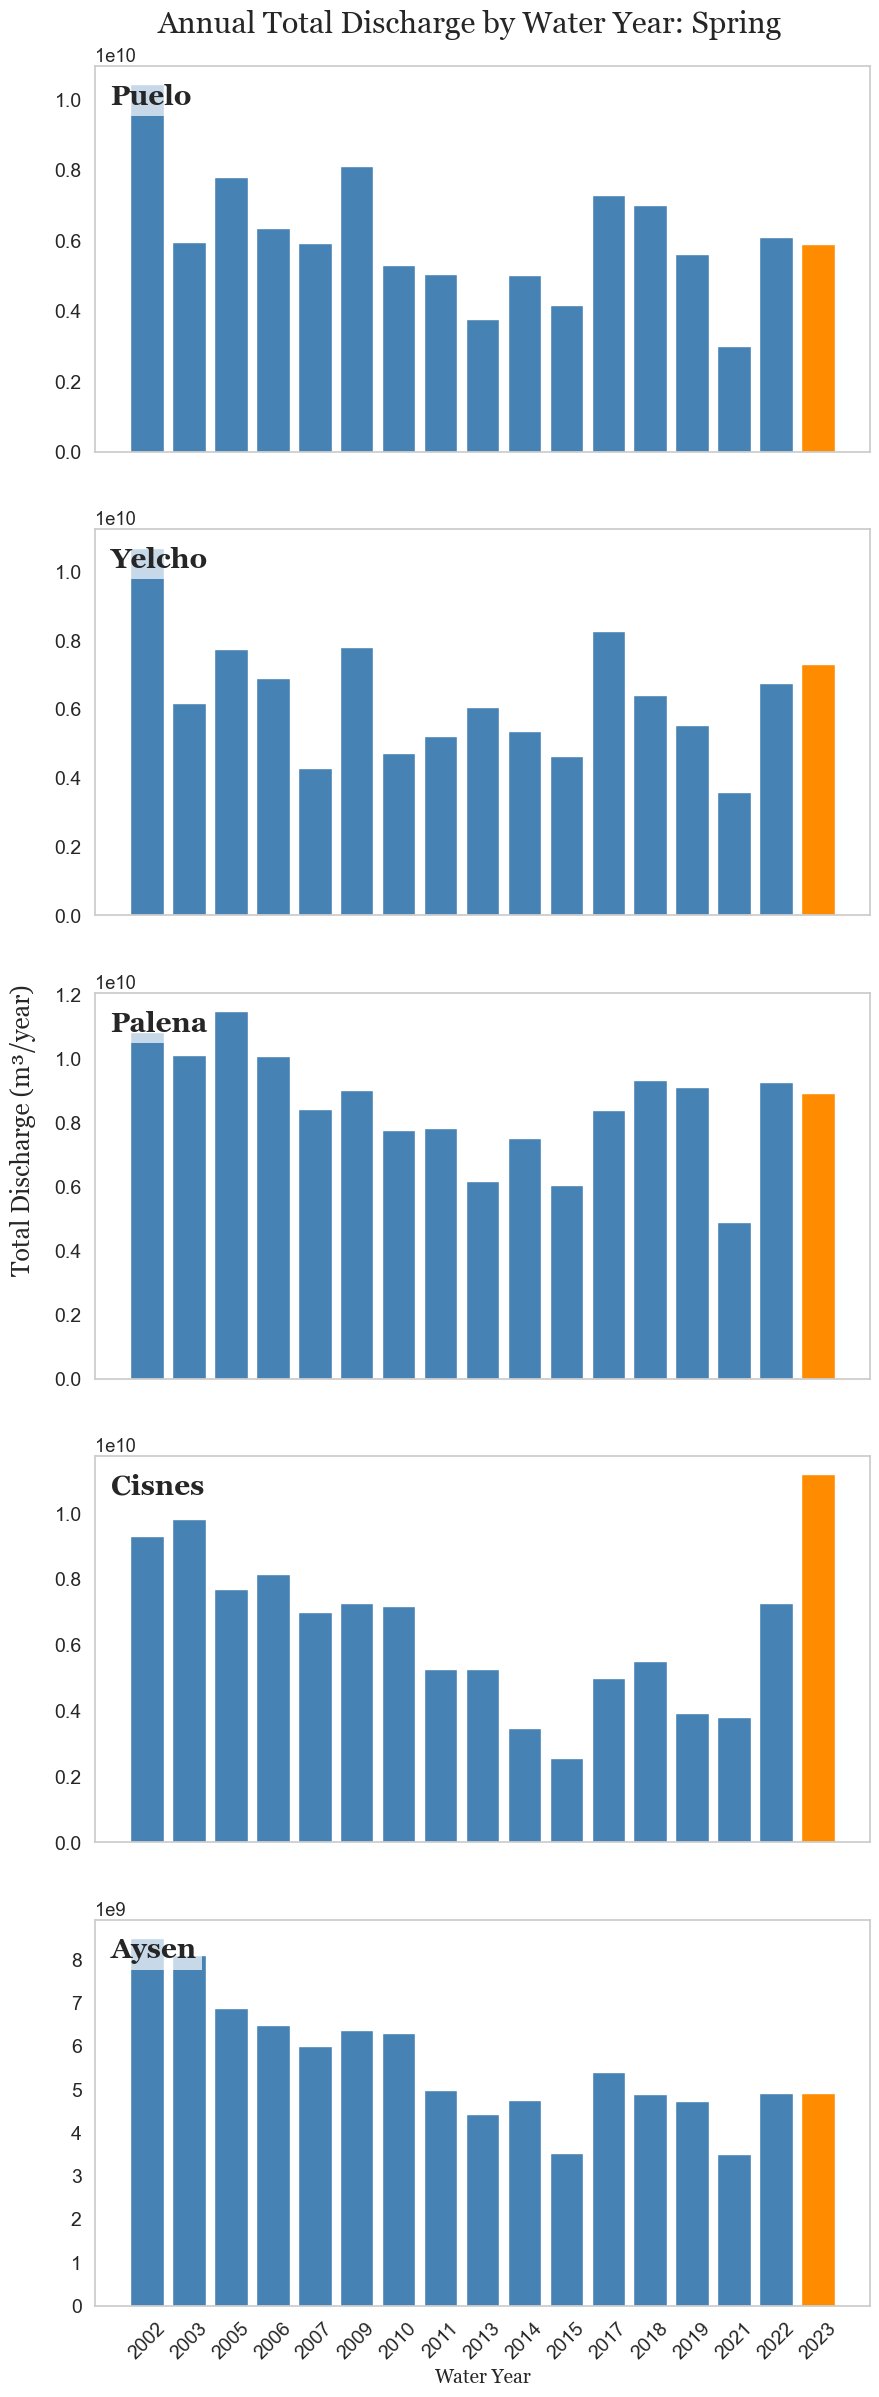

/var/folders/x8/mpvljg_94_nb_bqxjncltssw0000gn/T/ipykernel_83588/632481456.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])


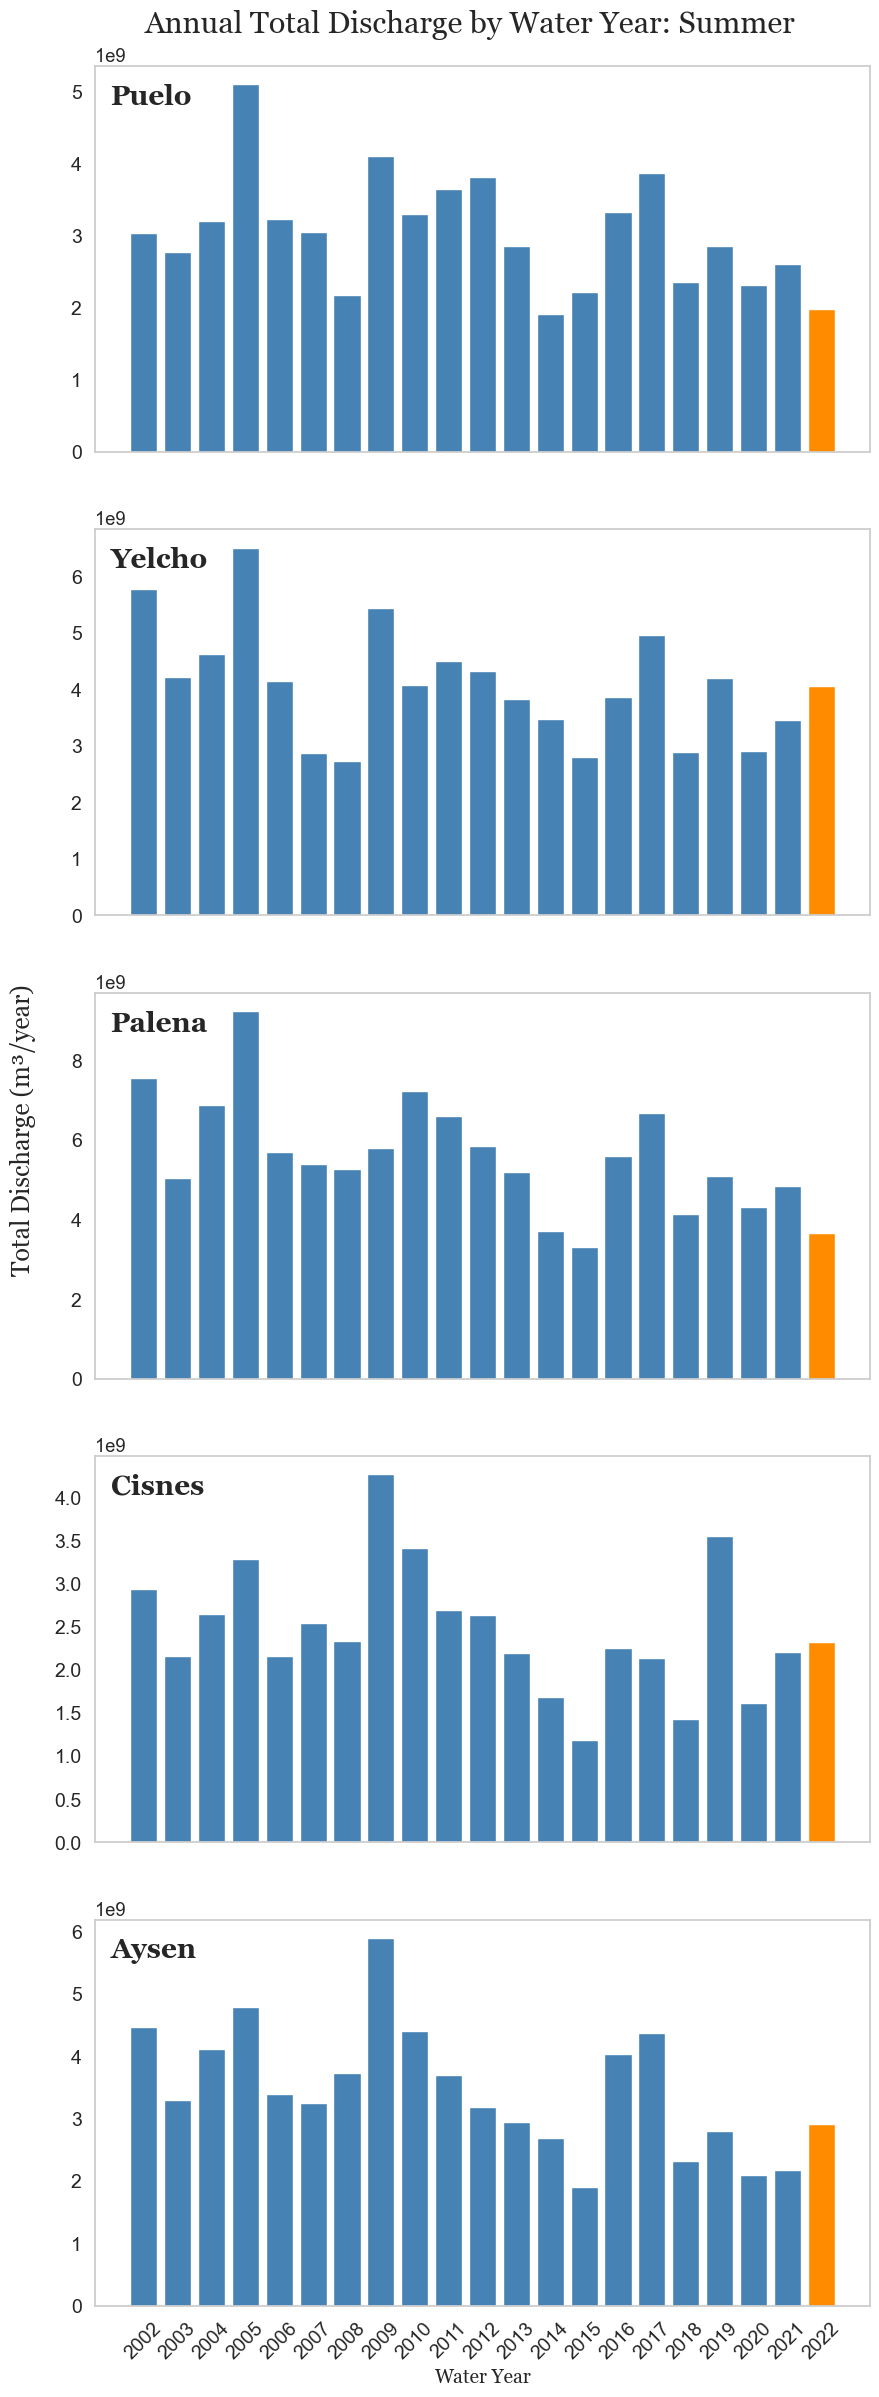

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from load_rivers import *  # This brings in raw_chem_dfs

# ===== USER-SET PARAMETERS =====
savefig = True

# ===== UTILITY FUNCTIONS =====
def water_year(date):
    """
    For a given date (pd.Timestamp), returns the water year.
    Water year runs from April 1 to March 31.
    If the month is January–March, assign the previous year.
    """
    return date.year - 1 if date.month < 4 else date.year

def expected_days_in_water_year(wy):
    """
    Returns the number of days in a water year that starts on April 1 of year wy
    and ends on March 31 of year wy+1.
    """
    start = pd.Timestamp(year=wy, month=4, day=1)
    end = pd.Timestamp(year=wy+1, month=3, day=31)
    return (end - start).days + 1

def expected_days_in_season(wy, season):
    """
    Returns the expected number of days for a full season in a water year.
    Seasons (based on southern hemisphere water-year starting April 1):
      - Fall:    April 1 – June 30      => 91 days
      - Winter:  July 1 – September 30    => 92 days
      - Spring:  October 1 – December 31    => 92 days
      - Summer:  January 1 – March 31       => depends on leap year
    """
    if season == "Fall":
        return 91
    elif season == "Winter":
        return 92
    elif season == "Spring":
        return 92
    elif season == "Summer":
        # Summer is Jan-Mar of the calendar year following the water-year start.
        year = wy + 1
        feb_days = 29 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 28
        return 31 + feb_days + 31

def get_season(date):
    """
    Returns the season for a given date based on a water-year starting April 1:
      - Fall:    April 1 – June 30
      - Winter:  July 1 – September 30
      - Spring:  October 1 – December 31
      - Summer:  January 1 – March 31
    """
    m = date.month
    if 4 <= m <= 6:
        return "Fall"
    elif 7 <= m <= 9:
        return "Winter"
    elif 10 <= m <= 12:
        return "Spring"
    else:
        return "Summer"

# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary of the entire daily mean streamflow Series (in m³/s) for each river.
all_flow = {name: data[code] for name, code in zip(river_names, river_codes)}

# ===== COMPUTE ANNUAL TOTAL DISCHARGE FOR EACH RIVER =====
# Daily mean (m³/s) is converted to daily total (m³/day) by multiplying by 86400.
annual_totals = {}
for name in river_names:
    df = all_flow[name].dropna().to_frame(name="Flow")
    df["DailyTotal"] = df["Flow"] * 86400  # m³/day
    df["WaterYear"] = df.index.map(water_year)
    group = df.groupby("WaterYear")["DailyTotal"].agg(["sum", "count"])
    complete_groups = []
    for wy, row in group.iterrows():
        expected = expected_days_in_water_year(wy)
        if row["count"] == expected:
            complete_groups.append((wy, row["sum"]))
    river_df = pd.DataFrame(complete_groups, columns=["WaterYear", "TotalDischarge"])
    annual_totals[name] = river_df

# ===== DETERMINE SEASONAL TOTALS =====
# For each river, we split the daily data into seasons and then group by water year.
seasonal_totals = {}
for name in river_names:
    df = all_flow[name].dropna().to_frame(name="Flow")
    df["DailyTotal"] = df["Flow"] * 86400
    df["WaterYear"] = df.index.map(water_year)
    df["Season"] = df.index.map(get_season)
    # Group by water year and season.
    groups = df.groupby(["WaterYear", "Season"])["DailyTotal"].agg(["sum", "count"]).reset_index()
    records = []
    for idx, row in groups.iterrows():
        wy = row["WaterYear"]
        season = row["Season"]
        expected = expected_days_in_season(wy, season)
        if row["count"] == expected:
            records.append((wy, season, row["sum"]))
    season_df = pd.DataFrame(records, columns=["WaterYear", "Season", "TotalDischarge"])
    seasonal_totals[name] = season_df

# ===== DETERMINE COMMON WATER YEARS FOR EACH SEASON ACROSS ALL RIVERS =====
common_years_by_season = {}
seasons = ["Fall", "Winter", "Spring", "Summer"]
for season in seasons:
    common_years = set(seasonal_totals[river_names[0]].loc[seasonal_totals[river_names[0]]["Season"] == season, "WaterYear"])
    for name in river_names[1:]:
        years = set(seasonal_totals[name].loc[seasonal_totals[name]["Season"] == season, "WaterYear"])
        common_years = common_years.intersection(years)
    common_years_by_season[season] = sorted(common_years)

# Filter each river's seasonal DataFrame to only include common water years for that season.
for name in river_names:
    df = seasonal_totals[name]
    dfs = []
    for season in seasons:
        common_years = common_years_by_season[season]
        df_season = df[df["Season"] == season]
        df_season = df_season[df_season["WaterYear"].isin(common_years)]
        dfs.append(df_season)
    seasonal_totals[name] = pd.concat(dfs)

# ===== PLOTTING: One Panel Figure Per Season =====
# For each season, create a figure with 5 vertically stacked subplots (one per river).
default_color = "steelblue"
sampled_year_color = "darkorange"

for season in seasons:
    # Only process if there is at least one common water year for the season.
    common_years = common_years_by_season[season]
    if len(common_years) == 0:
        print(f"No common water years for {season}. Skipping.")
        continue
    sampled_year = common_years[-1]
    
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 28), sharex=True,
                             gridspec_kw={'hspace': 0.2})
    for ax in axes:
        ax.grid(False)
    
    for i, name in enumerate(river_names):
        ax = axes[i]
        df_plot = seasonal_totals[name]
        df_season = df_plot[df_plot["Season"] == season].sort_values("WaterYear")
        # Create a list of colors: if water year equals sampled_year, use sampled_year_color.
        bar_colors = [sampled_year_color if wy == sampled_year else default_color for wy in df_season["WaterYear"]]
        ax.bar(df_season["WaterYear"].astype(str), df_season["TotalDischarge"], color=bar_colors)
        # Remove individual y-axis label.
        ax.set_ylabel("")
        # Remove x-axis label for all but the bottom subplot.
        if i < 4:
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Water Year", fontsize=14, fontname="Georgia")
        # Overlay the river name on the subplot.
        ax.text(0.02, 0.90, name, transform=ax.transAxes, fontsize=20, fontname="Georgia",
                fontweight="bold", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        # Adjust tick parameters.
        ax.tick_params(axis='x', labelrotation=45, labelsize=14)
        ax.tick_params(axis='y', labelsize=14)
    
    # Add a common x-axis label.
    fig.text(0.04, 0.5, "Total Discharge (m³/year)", va="center", rotation="vertical", fontsize=18, fontname="Georgia")
    # Add a common title for the panel indicating the season.
    fig.suptitle(f"Annual Total Discharge by Water Year: {season}", fontsize=22, fontname="Georgia", y=0.90)
    
    # (Optional) Remove extra space below the subplots if desired:
    plt.subplots_adjust(bottom=0.08)
    
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    fname = f"../../../figures/hydrological/water_year_stats/seasonal_total_discharge_{season}.jpeg"
    if savefig:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()


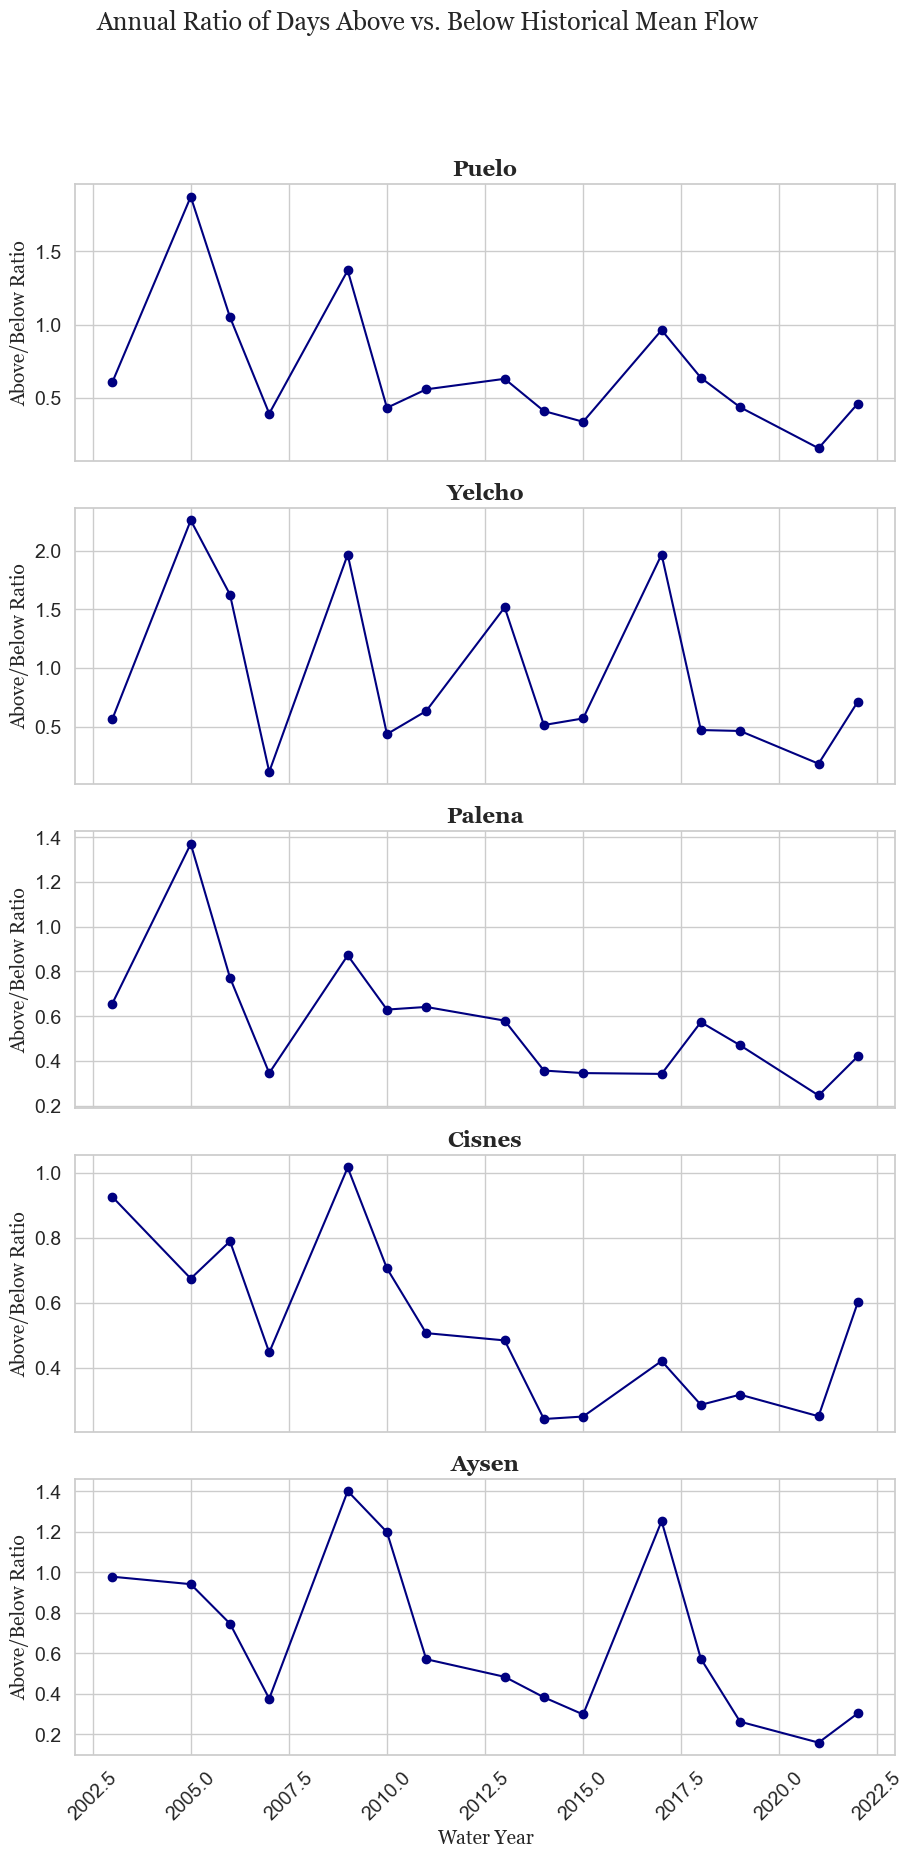

Annual Above/Below Ratio for Each River:
    WaterYear  Above  Below  count     Ratio  River
17       2003    138    228    366  0.605263  Puelo
18       2005    238    127    365  1.874016  Puelo
19       2006    187    178    365  1.050562  Puelo
20       2007    103    263    366  0.391635  Puelo
21       2009    211    154    365  1.370130  Puelo
..        ...    ...    ...    ...       ...    ...
95       2017    203    162    365  1.253086  Aysen
96       2018    133    232    365  0.573276  Aysen
97       2019     76    290    366  0.262069  Aysen
98       2021     50    315    365  0.158730  Aysen
99       2022     85    280    365  0.303571  Aysen

[75 rows x 6 columns]


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from load_rivers import *  # This brings in raw_chem_dfs

# ===== UTILITY FUNCTIONS =====
def water_year(date):
    """
    For a given date (pd.Timestamp), returns the water year.
    Water year runs from April 1 to March 31.
    If the month is January–March, assign the previous calendar year.
    """
    return date.year - 1 if date.month < 4 else date.year

def expected_days_in_water_year(wy):
    """
    Returns the number of days in a full water year (April 1 to March 31)
    for water year wy.
    """
    start = pd.Timestamp(year=wy, month=4, day=1)
    end = pd.Timestamp(year=wy+1, month=3, day=31)
    return (end - start).days + 1

# ===== LOAD HISTORICAL MEAN PATTERN (per julian date) =====
# For each river, compute the mean daily flow (m³/s) for each day-of-year using the entire record.
historical_mean = {}
for name in raw_chem_dfs.keys():
    # Load full streamflow data.
    file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
    data = pd.read_csv(file_path, parse_dates=['Date'])
    data.set_index("Date", inplace=True)
    data.index = pd.to_datetime(data.index)
    # Define a mapping for river codes (adjust if needed).
    river_codes = {"Puelo": "Puelo", "Yelcho": "Yelcho", "Palena": "Palena", "Cisnes": "Cisnes", "Aysen": "Aysen"}
    series = data[river_codes[name]].dropna()
    df = series.to_frame(name="Flow")
    df["DOY"] = df.index.dayofyear
    hm = df.groupby("DOY")["Flow"].mean()
    historical_mean[name] = hm

# ===== LOAD STREAMFLOW DATA (for all rivers) =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
all_flow = {name: data[code].dropna() for name, code in zip(river_names, river_codes)}

# ===== FOR EACH RIVER, CALCULATE THE ANNUAL ABOVE/BELOW RATIO USING WATER YEARS =====
results_list = []
for name in river_names:
    series = all_flow[name]
    # Create a DataFrame with Date and Flow.
    df = series.to_frame(name="Flow").copy()
    # Map each date to its water year.
    df["WaterYear"] = df.index.map(water_year)
    df["DOY"] = df.index.dayofyear
    # Map each row to its historical mean flow (for that DOY).
    df["HistMean"] = df["DOY"].map(historical_mean[name])
    # Label each day: 1 if Flow > HistMean, 0 if Flow <= HistMean.
    df["Above"] = (df["Flow"] > df["HistMean"]).astype(int)
    df["Below"] = (df["Flow"] <= df["HistMean"]).astype(int)
    # Group by WaterYear and sum.
    yearly = df.groupby("WaterYear").agg({"Above": "sum", "Below": "sum", "Flow": "count"}).rename(columns={"Flow": "count"})
    yearly = yearly.reset_index()
    # Only keep complete water years.
    yearly = yearly[yearly.apply(lambda row: row["count"] == expected_days_in_water_year(row["WaterYear"]), axis=1)]
    # Calculate ratio; if Below==0, set ratio to NaN.
    yearly["Ratio"] = yearly["Above"] / yearly["Below"].replace(0, np.nan)
    yearly["River"] = name
    yearly = yearly.reset_index(drop=True)
    results_list.append(yearly)
    
# Combine results for all rivers into a single DataFrame.
ratio_df = pd.concat(results_list, ignore_index=True)

# ===== LIMIT TO COMMON WATER YEARS ACROSS ALL RIVERS =====
common_years = set(ratio_df[ratio_df["River"] == river_names[0]]["WaterYear"])
for name in river_names[1:]:
    common_years = common_years.intersection(set(ratio_df[ratio_df["River"] == name]["WaterYear"]))
common_years = sorted(common_years)
# Filter ratio_df to include only common water years.
ratio_df = ratio_df[ratio_df["WaterYear"].isin(common_years)]

# ===== PLOTTING: PANEL FIGURE WITH 5 SUBPLOTS (one per river) =====
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), sharex=True)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical space as needed

for i, name in enumerate(river_names):
    ax = axes[i]
    df_plot = ratio_df[ratio_df["River"] == name].sort_values("WaterYear")
    ax.plot(df_plot["WaterYear"], df_plot["Ratio"], marker="o", linestyle="-", color="navy")
    ax.set_title(name, fontsize=16, fontname="Georgia", fontweight="bold")
    ax.set_ylabel("Above/Below Ratio", fontsize=14, fontname="Georgia")
    ax.tick_params(axis="x", labelsize=14, rotation=45)
    ax.tick_params(axis="y", labelsize=14)
    
# Set common x-axis label.
axes[-1].set_xlabel("Water Year", fontsize=14, fontname="Georgia")
    
fig.suptitle("Annual Ratio of Days Above vs. Below Historical Mean Flow", fontsize=18, fontname="Georgia", y=0.98)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.94])
if savefig:
    plt.savefig("annual_flow_above_below_ratio_by_river.jpeg", bbox_inches="tight")
plt.show()

print("Annual Above/Below Ratio for Each River:")
print(ratio_df)


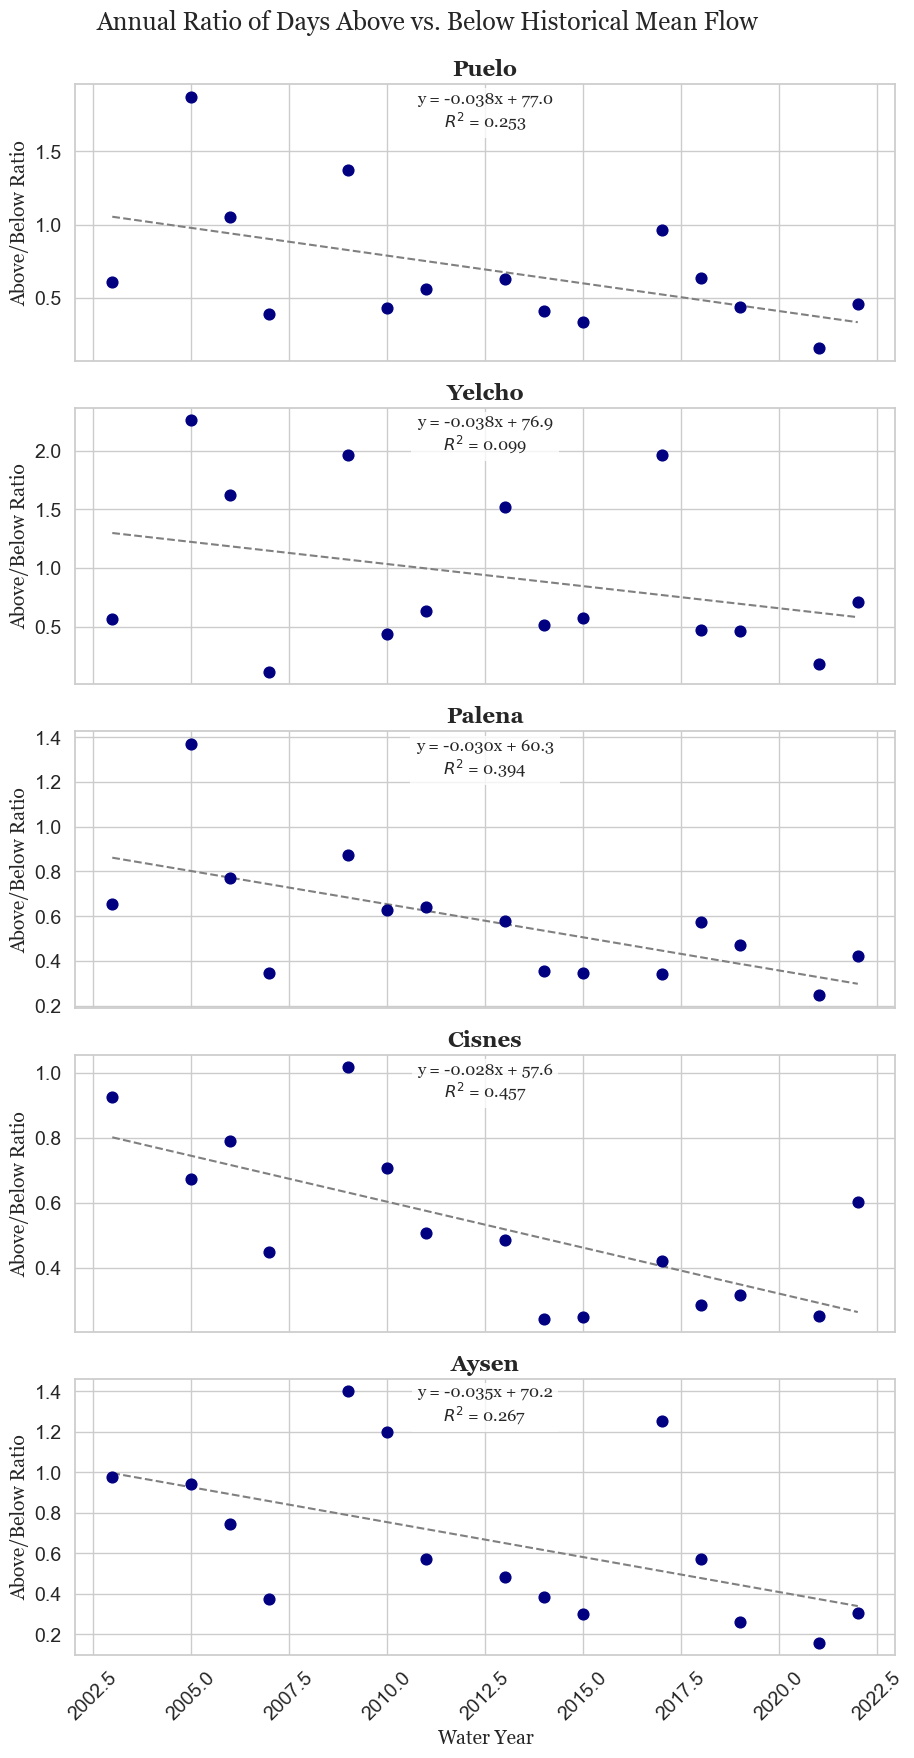

Annual Above/Below Ratio for Each River:
    WaterYear  Above  Below  count     Ratio  River
17       2003    138    228    366  0.605263  Puelo
18       2005    238    127    365  1.874016  Puelo
19       2006    187    178    365  1.050562  Puelo
20       2007    103    263    366  0.391635  Puelo
21       2009    211    154    365  1.370130  Puelo
..        ...    ...    ...    ...       ...    ...
95       2017    203    162    365  1.253086  Aysen
96       2018    133    232    365  0.573276  Aysen
97       2019     76    290    366  0.262069  Aysen
98       2021     50    315    365  0.158730  Aysen
99       2022     85    280    365  0.303571  Aysen

[75 rows x 6 columns]


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from load_rivers import *  # This brings in raw_chem_dfs
from scipy.stats import linregress

# ===== UTILITY FUNCTIONS =====
def water_year(date):
    """
    For a given date (pd.Timestamp), returns the water year.
    Water year runs from April 1 to March 31.
    If the month is January–March, assign the previous calendar year.
    """
    return date.year - 1 if date.month < 4 else date.year

def expected_days_in_water_year(wy):
    """
    Returns the number of days in a full water year (April 1 to March 31)
    for water year wy.
    """
    start = pd.Timestamp(year=wy, month=4, day=1)
    end = pd.Timestamp(year=wy+1, month=3, day=31)
    return (end - start).days + 1

# ===== LOAD HISTORICAL MEAN PATTERN (per julian date) =====
# For each river, compute the mean daily flow (m³/s) for each day-of-year using the entire record.
historical_mean = {}
for name in raw_chem_dfs.keys():
    file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
    data = pd.read_csv(file_path, parse_dates=['Date'])
    data.set_index("Date", inplace=True)
    data.index = pd.to_datetime(data.index)
    # Assume keys are the same as in raw_chem_dfs.
    river_codes = {"Puelo": "Puelo", "Yelcho": "Yelcho", "Palena": "Palena", "Cisnes": "Cisnes", "Aysen": "Aysen"}
    series = data[river_codes[name]].dropna()
    df = series.to_frame(name="Flow")
    df["DOY"] = df.index.dayofyear
    hm = df.groupby("DOY")["Flow"].mean()
    historical_mean[name] = hm

# ===== LOAD STREAMFLOW DATA (for all rivers) =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
all_flow = {name: data[code].dropna() for name, code in zip(river_names, river_codes)}

# ===== FOR EACH RIVER, CALCULATE THE ANNUAL ABOVE/BELOW RATIO USING WATER YEARS =====
results_list = []
for name in river_names:
    series = all_flow[name]
    df = series.to_frame(name="Flow").copy()
    df["WaterYear"] = df.index.map(water_year)
    df["DOY"] = df.index.dayofyear
    df["HistMean"] = df["DOY"].map(historical_mean[name])
    df["Above"] = (df["Flow"] > df["HistMean"]).astype(int)
    df["Below"] = (df["Flow"] <= df["HistMean"]).astype(int)
    yearly = df.groupby("WaterYear").agg({"Above": "sum", "Below": "sum", "Flow": "count"}).rename(columns={"Flow": "count"})
    yearly = yearly.reset_index()
    # Keep only complete water years.
    yearly = yearly[yearly.apply(lambda row: row["count"] == expected_days_in_water_year(row["WaterYear"]), axis=1)]
    yearly["Ratio"] = yearly["Above"] / yearly["Below"].replace(0, np.nan)
    yearly["River"] = name
    yearly = yearly.reset_index(drop=True)
    results_list.append(yearly)
    
ratio_df = pd.concat(results_list, ignore_index=True)

# ===== LIMIT TO COMMON WATER YEARS ACROSS ALL RIVERS =====
common_years = set(ratio_df[ratio_df["River"] == river_names[0]]["WaterYear"])
for name in river_names[1:]:
    common_years = common_years.intersection(set(ratio_df[ratio_df["River"] == name]["WaterYear"]))
common_years = sorted(common_years)
ratio_df = ratio_df[ratio_df["WaterYear"].isin(common_years)]

# ===== PLOTTING: PANEL FIGURE WITH 5 SUBPLOTS (One Per River) =====
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), sharex=True)
plt.subplots_adjust(hspace=0.3)  # Adjust vertical space as needed

for i, name in enumerate(river_names):
    ax = axes[i]
    df_plot = ratio_df[ratio_df["River"] == name].sort_values("WaterYear")
    # Plot the ratio data as scatter points (no connecting line).
    ax.scatter(df_plot["WaterYear"], df_plot["Ratio"], color="navy", marker="o", s=60, zorder=10)
    
    # Fit a line of best fit using linregress.
    x = df_plot["WaterYear"].values
    y = df_plot["Ratio"].values
    result = linregress(x, y)
    slope, intercept, r_value, p_value, std_err = result.slope, result.intercept, result.rvalue, result.pvalue, result.stderr
    r_squared = r_value**2
    # Compute fitted line values.
    y_fit = slope * x + intercept
    ax.plot(x, y_fit, color="gray", linestyle="--", zorder=5)
    
    # Annotate the regression equation and R^2 above the subplot.
    eq_text = f"y = {slope:.3f}x + {intercept:.1f}\n$R^2$ = {r_squared:.3f}"
    # Place annotation using axes coordinates (x=0.5, y=0.9).
    ax.text(0.5, 0.90, eq_text, transform=ax.transAxes, fontsize=12, fontname="Georgia",
            ha="center", va="center", bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
    
    ax.set_title(name, fontsize=16, fontname="Georgia", fontweight="bold")
    ax.set_ylabel("Above/Below Ratio", fontsize=14, fontname="Georgia")
    ax.tick_params(axis="x", labelsize=14, rotation=45)
    ax.tick_params(axis="y", labelsize=14)

# Set common x-axis label.
axes[-1].set_xlabel("Water Year", fontsize=14, fontname="Georgia")
    
fig.suptitle("Annual Ratio of Days Above vs. Below Historical Mean Flow", fontsize=18, fontname="Georgia", y=0.93)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.94])
if savefig:
    plt.savefig("../../../figures/hydrological/water_year_stats/wet_to_dry_ratio.jpeg", bbox_inches="tight")
plt.show()

print("Annual Above/Below Ratio for Each River:")
print(ratio_df)


In [20]:
import pandas as pd
import numpy as np

# ===== USER-SET PARAMETERS =====
savefig = True
# Set the CSV save path (adjust as needed)
csv_save_path = "../../../data/streamflow/water_year_stats/water_year_stats.csv"

# ===== LOAD STREAMFLOW DATA =====
file_path = "../../../data/streamflow/est_outlet_flow/Downstream_Estimate_All_Rivers_rolling60.csv"
data = pd.read_csv(file_path, parse_dates=['Date'])
data.set_index("Date", inplace=True)
data.index = pd.to_datetime(data.index)

# Define river codes and names.
river_codes = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]
river_names = ["Puelo", "Yelcho", "Palena", "Cisnes", "Aysen"]

# Create a dictionary mapping each river name to its daily mean streamflow Series.
all_flow = {name: data[code].dropna() for name, code in zip(river_names, river_codes)}

# ===== DEFINE CONTEMPORARY AND HISTORICAL PERIODS =====
# Contemporary water year: April 1, 2022 to March 31, 2023
contemporary_start = pd.Timestamp("2022-04-01")
contemporary_end   = pd.Timestamp("2023-03-31")
# Historical period: all data strictly before April 1, 2022.
historical_end   = pd.Timestamp("2022-03-31")

# ===== COMPUTE STATISTICS FOR EACH RIVER AND PERIOD =====
results = []  # List to store dictionaries with statistics

for river in river_names:
    series = all_flow[river]
    
    # Extract contemporary data for the water year
    cont_data = series.loc[contemporary_start:contemporary_end]
    # Extract historical data (all data strictly before contemporary_start)
    hist_data = series.loc[:historical_end]
    
    # Function to compute statistics from a pd.Series
    def compute_stats(s):
        if s.empty:
            return {"Mean": np.nan, "Median": np.nan, "Mode": np.nan, "Min": np.nan, "Max": np.nan}
        mean_val = s.mean()
        median_val = s.median()
        mode_vals = s.mode()
        mode_val = mode_vals.iloc[0] if not mode_vals.empty else np.nan
        min_val = s.min()
        max_val = s.max()
        return {"Mean": mean_val, "Median": median_val, "Mode": mode_val, "Min": min_val, "Max": max_val}
    
    cont_stats = compute_stats(cont_data)
    hist_stats = compute_stats(hist_data)
    
    # Append results for contemporary period.
    results.append({
        "River": river,
        "Period": "Contemporary (2022-23)",
        **cont_stats
    })
    # Append results for historical period.
    results.append({
        "River": river,
        "Period": "Historical (Pre-2022)",
        **hist_stats
    })

# Create a DataFrame from the results.
summary_df = pd.DataFrame(results)

# Print the summary table.
print("Streamflow Summary Statistics:")
print(summary_df)

# Save the table as CSV.
if savefig:
    summary_df.to_csv(csv_save_path, index=False)
    print(f"Summary saved to {csv_save_path}")


Streamflow Summary Statistics:
    River                  Period        Mean      Median        Mode  \
0   Puelo  Contemporary (2022-23)  569.806349  534.520719  189.517404   
1   Puelo   Historical (Pre-2022)  610.079089  507.879056  221.024541   
2  Yelcho  Contemporary (2022-23)  685.772310  682.916880  306.061429   
3  Yelcho   Historical (Pre-2022)  729.589134  690.655082  307.266155   
4  Palena  Contemporary (2022-23)  835.735544  665.071098  245.746376   
5  Palena   Historical (Pre-2022)  921.232458  747.316516  934.566313   
6  Cisnes  Contemporary (2022-23)  500.720388  352.761453   88.495209   
7  Cisnes   Historical (Pre-2022)  460.542803  327.065756  199.779615   
8   Aysen  Contemporary (2022-23)  490.860830  396.887394  171.977672   
9   Aysen   Historical (Pre-2022)  601.435990  507.706820  370.895545   

          Min          Max  
0  189.517404  1720.515254  
1  102.998579  5279.979654  
2  306.061429  1369.053249  
3  205.618209  3879.063025  
4  245.746376  3456.